[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/ER_NCA.ipynb)

In [1]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}



import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))



Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 811, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 811 (delta 51), reused 0 (delta 0), pack-reused 722 (from 1)
Receiving objects: 100% (811/811), 28.96 MiB | 21.57 MiB/s, done.
Resolving deltas: 100% (470/470), done.
Success! Files now found: ['NCA_baseline.py', 'pathway.py', 'ER_NCA.ipynb', 'utils.py', 'NCA.py', 'EBM_NCA_baseline.ipynb', '.git', 'README.md', 'EBM_NCA.ipynb', 'Images']


In [2]:
#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
import pandas as pd
from base64 import b64encode
from sklearn.decomposition import PCA
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)

Using device: cuda


In [3]:

#@title Setup { vertical-output: true}
HEIGHT = 35 #@param {type:"integer"}
WIDTH = 35 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 3000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size


style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""



In [4]:
LIZARD = "Images/lizard.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING

In [5]:


class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = list(slots.keys())
    self._size = None

    # Store standard slots (e.g., x)
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

    # Initialize or pass age tracking array
    if _parent is None and 'age' not in slots:
      self.age = np.zeros(self._size, dtype=np.int32)
      self._slot_names.append('age')
    elif 'age' in slots:
      self.age = np.asarray(slots['age'], dtype=np.int32)

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self, steps_taken=0, reset_mask=None):
    """
    Commits batch states back to parent pool, increments age by steps_taken,
    and resets age to 0 for replaced seed samples.
    """
    if reset_mask is not None:
      # Reset age to 0 for seed replacements before adding step count
      self.age[reset_mask] = 0

    # Increment age by rollout steps
    self.age += steps_taken

    # Write back to parent pool
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

  def prune_old_states(self, max_age, seed_np):
    """
    Hard-resets any samples in the main pool exceeding max_age back to fresh seeds.
    """
    too_old = self.age > max_age
    if np.any(too_old):
      # Ensure seed_np broadcast shape matches the slot layout
      if seed_np.ndim == 3 and hasattr(self, 'x'):
        self.x[too_old] = seed_np
      elif seed_np.ndim == 4 and hasattr(self, 'x'):
        self.x[too_old] = seed_np[0]

      self.age[too_old] = 0




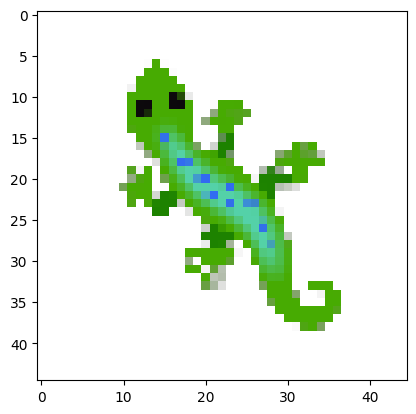

In [6]:


#@title Display Primitives { vertical-output: true}
def make_seed(size, channels=16):
    x = np.zeros([channels, size, size], dtype=np.float32)
    x[3:, size // 2, size // 2] = 1.0
    return x

seed = make_seed(HEIGHT, CHANNELS)

pool_inputs = np.repeat(seed[None, ...], POOL_SIZE, axis=0)
pool = SamplePool(x=pool_inputs)


plt.imshow(image_to_display)
plt.show()



In [7]:
batch = pool.sample(BATCH_SIZE)

In [8]:
sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "weights"

In [9]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/weights already exists, all OK!


In [10]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = HYBRID_NCA(CHANNELS,HIDDEN_SIZE)
nca = HYBRID_NCA(CHANNELS, HIDDEN_SIZE).to(DEVICE)
optim = torch.optim.AdamW([
    # Group 1: Standard Neural Path (Conv Layers: w1, w2)
    {
        'params': list(nca.w1.parameters()) + list(nca.w2.parameters()),
        'lr': 1e-3,
        'weight_decay': 1e-4
    },

    # Group 2: Energy Matrix (W)
    {
        'params': [nca.W],
        'lr': 1e-3,
        'weight_decay': 1e-3
    },

    # Group 3: Energy Bias (h)
    {
        'params': [nca.h],
        'lr': 1e-4,
        'weight_decay': 0.0
    },

    # Group 4: Step-size & Diffusion parameters (eta, beta)
    {
        'params': [nca.eta, nca.beta],
        'lr': 1e-3,
        'weight_decay': 0.0
    }
])
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__

In [11]:
def create_circular_mask(HEIGHT, WIDTH, center_x, center_y, radius, device="cuda:0"):
    height, width = HEIGHT, WIDTH
    y_grid, x_grid = torch.meshgrid(
        torch.arange(height, device=device),
        torch.arange(width, device=device),
        indexing='ij'
    )
    distance_squared = (x_grid - center_x) ** 2 + (y_grid - center_y) ** 2
    return distance_squared <= (radius ** 2)



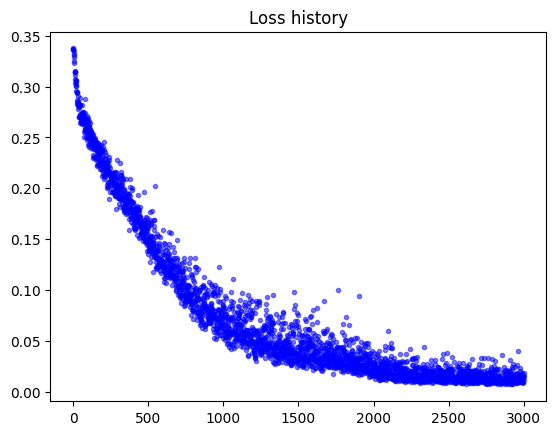

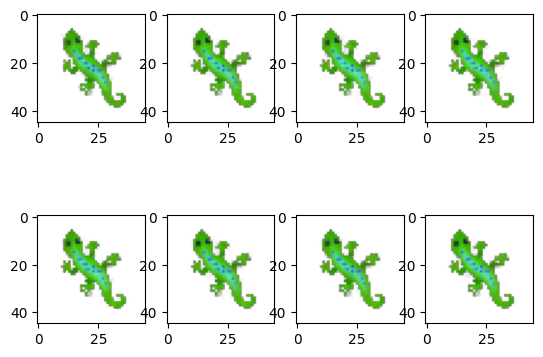

In [12]:
#@title Training { vertical-output: true}
DAMAGE_N = 0
lambda_mono = 0.1
lambda_drift = 0.5
K = 10

# Pre-compute dilated target perimeter mask for sharp edge gradients
with torch.no_grad():
    target_mask = (base[:, 3:4] > 0.1).float()
    bg_mask = (base[:, 3:4] <= 0.1).float()

    # 3x3 Dilation to isolate target perimeter
    dilated_target = F.max_pool2d(target_mask, kernel_size=3, stride=1, padding=1)
    boundary_zone = dilated_target - target_mask

loss_log = []

for i in range(TRAINING_ITERS + 1):

    # 1. Pool Sampling & Manipulation
    with torch.no_grad():
        batch = pool.sample(BATCH_SIZE)
        x0_tensor = torch.from_numpy(batch.x).to(DEVICE)

        # Rank samples by loss (highest to lowest)
        pre_pixel_loss = (x0_tensor[:, :4] - base).pow(2).mean(dim=[1, 2, 3])
        loss_rank = pre_pixel_loss.cpu().numpy().argsort()[::-1]

        # Re-order all slots and parent tracking indices in the batch object
        for k in batch._slot_names:
            setattr(batch, k, getattr(batch, k)[loss_rank])
        batch._parent_idx = batch._parent_idx[loss_rank]

        # Format numpy seed
        seed_np = seed.detach().cpu().numpy() if isinstance(seed, torch.Tensor) else seed.copy()
        if seed_np.ndim == 4:
            seed_np = seed_np[0]

        # Mask worst 10% for seed replacement
        num_resets = max(1, int(BATCH_SIZE * 0.10))
        reset_mask = np.zeros(BATCH_SIZE, dtype=bool)
        reset_mask[:num_resets] = True

        # Overwrite worst samples directly in batch.x
        batch.x[reset_mask] = seed_np

        # Apply circular damage if enabled
        if DAMAGE_N > 0:
            for idx in range(1, DAMAGE_N + 1):
                cx = random.randint(int(WIDTH * 0.2), int(WIDTH * 0.8))
                cy = random.randint(int(HEIGHT * 0.2), int(HEIGHT * 0.8))
                r = random.randint(4, 10)

                mask_np = create_circular_mask(HEIGHT, WIDTH, cx, cy, radius=r).cpu().numpy().astype(np.float32)
                if mask_np.ndim == 2:
                    mask_np = mask_np[None, ...]

                damage = 1.0 - mask_np
                batch.x[-idx, :3] *= damage

        # Send batch to GPU
        x = torch.from_numpy(batch.x).to(DEVICE)

    # 2. Forward Rollout (Extended T for Long-Horizon Stability)
    T = random.randrange(64, 94)
    energies = [nca.energy(x)]
    for t in range(T):
        x = nca(x)
        energies.append(nca.energy(x))

    # 3. Target Discrepancy (Identical to Baseline)
    pixel_loss = (x[:, :4] - base).pow(2).mean(dim=[1, 2, 3])

    # Run Sobel filters over ALL channels and ALL interior pixels (eyes, spots, edges)
    edge_loss = (perchannel_conv(base, filters) - perchannel_conv(x[:, :4], filters)).pow(2).mean(dim=[1, 2, 3])

    loss_recon = (pixel_loss + 0.4 * edge_loss).mean()

    # 4. K-Step Drift Stability (Identical formulation)
    x_drift = x.detach().clone()
    loss_drift = 0.0
    for t in range(K):
        x_drift = nca(x_drift)
        drift_pixel = (x_drift[:, :4] - base).pow(2).mean(dim=[1, 2, 3])
        drift_edge = (perchannel_conv(base, filters) - perchannel_conv(x_drift[:, :4], filters)).pow(2).mean(dim=[1, 2, 3])
        loss_drift = loss_drift + (drift_pixel + 0.4 * drift_edge).mean()

    loss_drift = loss_drift / K

    # 5. Monotonicity Regularization
    energies_t = torch.stack(energies[:-1])
    energies_t1 = torch.stack(energies[1:])
    loss_mono = torch.relu(energies_t1 - energies_t).mean()

    # Clean Composite Loss
    loss = loss_recon + (lambda_mono * loss_mono) + (lambda_drift * loss_drift)

    # 7. Optimization Step
    optim.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(nca.parameters(), max_norm=1.0)
    optim.step()
    scheduler.step()

    # 8. Commit States to Pool
    with torch.no_grad():
        batch.x = x.detach().cpu().numpy()
        batch.commit(steps_taken=T, reset_mask=reset_mask)

        # Extended age pruning threshold
        if i % 50 == 0:
            pool.prune_old_states(max_age=500, seed_np=seed_np)

    # Logging
    loss_log.append(loss_recon.detach().item())

    if i % 100 == 0:
        print(f"Training iter {i}, loss = {loss.item():.5f}")
        plt.clf()
        clear_output()
        plt.figure(1, figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color="b")
        utils.show_batch(x[-8:])  # Display mature states from batch
        plt.show(block=False)
        plt.pause(0.01)

        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")

In [13]:
del nca
del optim
torch.cuda.empty_cache()

In [14]:
nca = HYBRID_NCA(CHANNELS,hidden_n=HIDDEN_SIZE)
nca.load_state_dict(torch.load("Trained_models/weights/HYBRID_NCA.pth"))
nca.to(DEVICE).eval()



HYBRID_NCA(
  (w1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
)

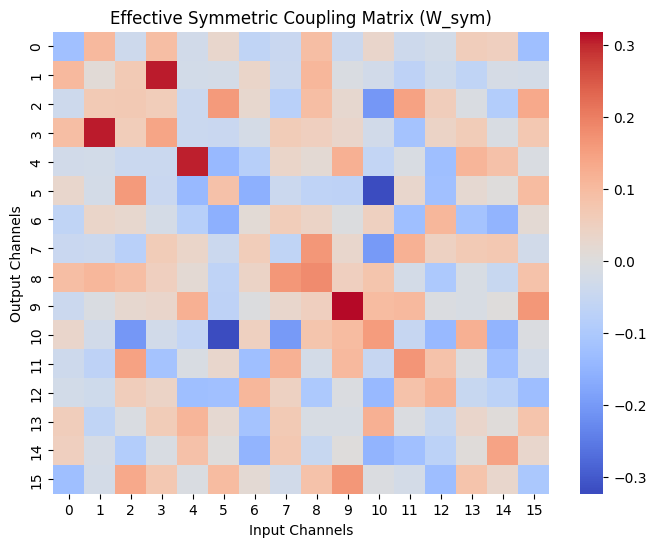

In [15]:
import seaborn as sns
with torch.no_grad():
    W_effective = nca._get_constrained_W().cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(W_effective, cmap="coolwarm", center=0, annot=False)
plt.title("Effective Symmetric Coupling Matrix (W_sym)")
plt.xlabel("Input Channels")
plt.ylabel("Output Channels")
plt.show()


<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_19667/4204191986.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Eigenvalue Spectrum of $W_{\mathrm{sym}}$", fontsize=12)


=== Eigenvalue Spectrum Analysis ===
Min Eigenvalue (λ_min): -0.4836
Max Eigenvalue (λ_max): 0.7072
Positive Eigenvalues (Unstable Directions): 9 / 16
 Verdict: W_sym is Indefinite. The energy landscape contains SADDLE POINTS / UNSTABLE DIRECTIONS.


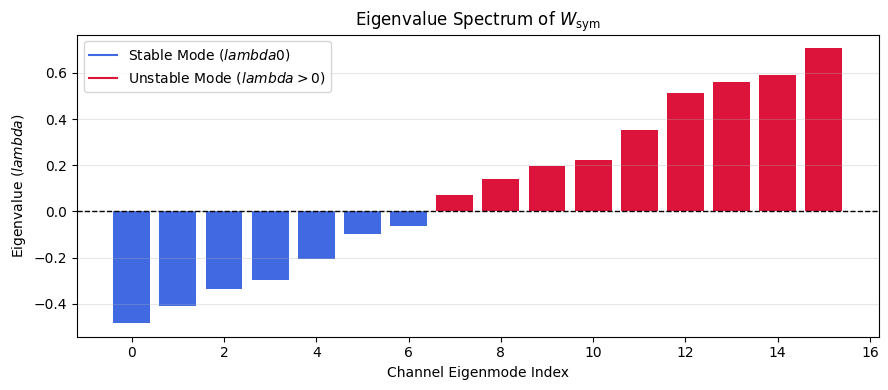

In [16]:
def analyze_energy_convexity(nca):
    # 1. Extract the symmetric matrix W_sym
    with torch.no_grad():
        W_sym = nca._get_constrained_W().cpu()

    # 2. Compute eigenvalues of W_sym (eigvalsh returns them sorted in ascending order)
    # Since W_sym is real and symmetric, all eigenvalues are guaranteed to be real
    eigenvalues = torch.linalg.eigvalsh(W_sym).numpy()

    # 3. Print Spectrum Summary
    max_ev = eigenvalues.max()
    min_ev = eigenvalues.min()
    num_positive = (eigenvalues > 0).sum()

    print("=== Eigenvalue Spectrum Analysis ===")
    print(f"Min Eigenvalue (λ_min): {min_ev:.4f}")
    print(f"Max Eigenvalue (λ_max): {max_ev:.4f}")
    print(f"Positive Eigenvalues (Unstable Directions): {num_positive} / {len(eigenvalues)}")

    if max_ev < 0:
        print(" Verdict: W_sym is Negative Definite. The quadratic energy landscape is STRICTLY CONVEX.")
    elif max_ev == 0 and min_ev <= 0:
        print(" Verdict: W_sym is Negative Semi-Definite. Convex with flat/zero-energy directions.")
    else:
        print(" Verdict: W_sym is Indefinite. The energy landscape contains SADDLE POINTS / UNSTABLE DIRECTIONS.")

    # 4. Plot Eigenvalue Spectrum
    plt.figure(figsize=(9, 4))

    # Bar plot of eigenvalues
    bars = plt.bar(range(len(eigenvalues)), eigenvalues, color=['crimson' if ev > 0 else 'royalblue' for ev in eigenvalues])

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title("Eigenvalue Spectrum of $W_{\mathrm{sym}}$", fontsize=12)
    plt.xlabel("Channel Eigenmode Index", fontsize=10)
    plt.ylabel("Eigenvalue ($lambda$)", fontsize=10)
    plt.grid(axis='y', alpha=0.3)

    # Annotate legend colors
    plt.plot([], [], color='royalblue', label='Stable Mode ($lambda  0$)')
    plt.plot([], [], color='crimson', label='Unstable Mode ($lambda > 0$)')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Run evaluation on your trained NCA instance
analyze_energy_convexity(nca)

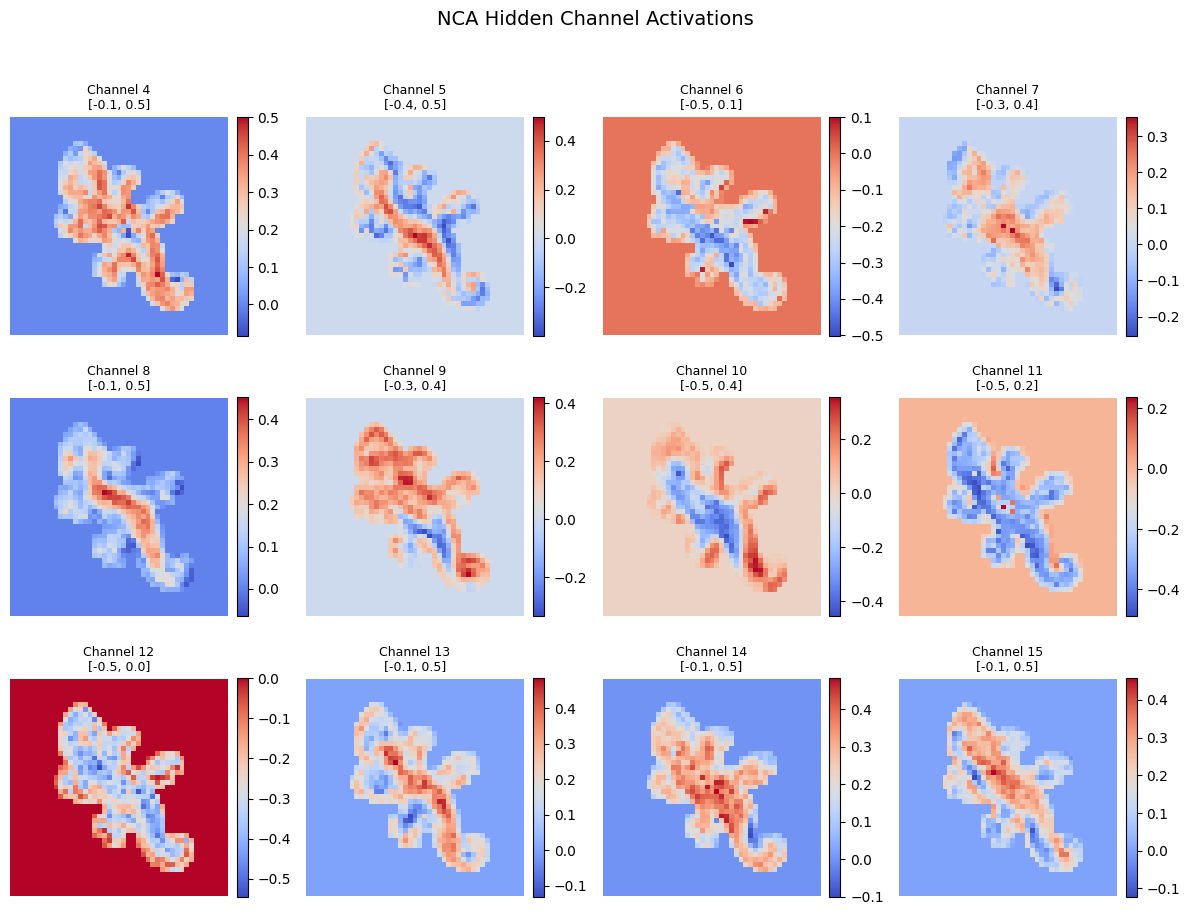

In [17]:
x = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.to(DEVICE)

with torch.no_grad():
    for t in range(400):
        x = nca(x)

# 2. Extract Hidden Channels (assuming channels 0..3 are RGBA)
# x shape: (1, total_channels, H, W)
hidden_channels = x[0, 4:].cpu().numpy()  # shape: (num_hidden_channels, H, W)
num_hidden = hidden_channels.shape[0]

# 3. Create a Grid of Heatmaps
cols = 4  # Display 4 heatmaps per row
rows = (num_hidden + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i in range(num_hidden):
    channel_data = hidden_channels[i]

    # Use a diverging colormap like 'coolwarm' or 'seismic' centered at 0
    # or 'viridis' to see relative magnitudes
    im = axes[i].imshow(channel_data, cmap='coolwarm')

    # Show min/max values in title to easily spot exploding values
    c_min, c_max = channel_data.min(), channel_data.max()
    axes[i].set_title(f"Channel {i+4}\n[{c_min:.1f}, {c_max:.1f}]", fontsize=9)
    axes[i].axis('off')

    # Optional: Add colorbar per subplot to inspect absolute values
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Turn off any unused subplots
for i in range(num_hidden, len(axes)):
    axes[i].axis('off')

plt.suptitle("NCA Hidden Channel Activations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
def find_convergence_step(mse_sequence, patience=10, delta_tol=1e-4, target_mse=0.005):
    patience_counter = 0
    prev_mse = float('inf')

    for i, current_mse in enumerate(mse_sequence):
        delta_mse = abs(prev_mse - current_mse)
        if current_mse < target_mse and delta_mse < delta_tol:
            patience_counter += 1
        else:
            patience_counter = 0

        if patience_counter >= patience:
            return i - patience + 1

        prev_mse = current_mse

    return None

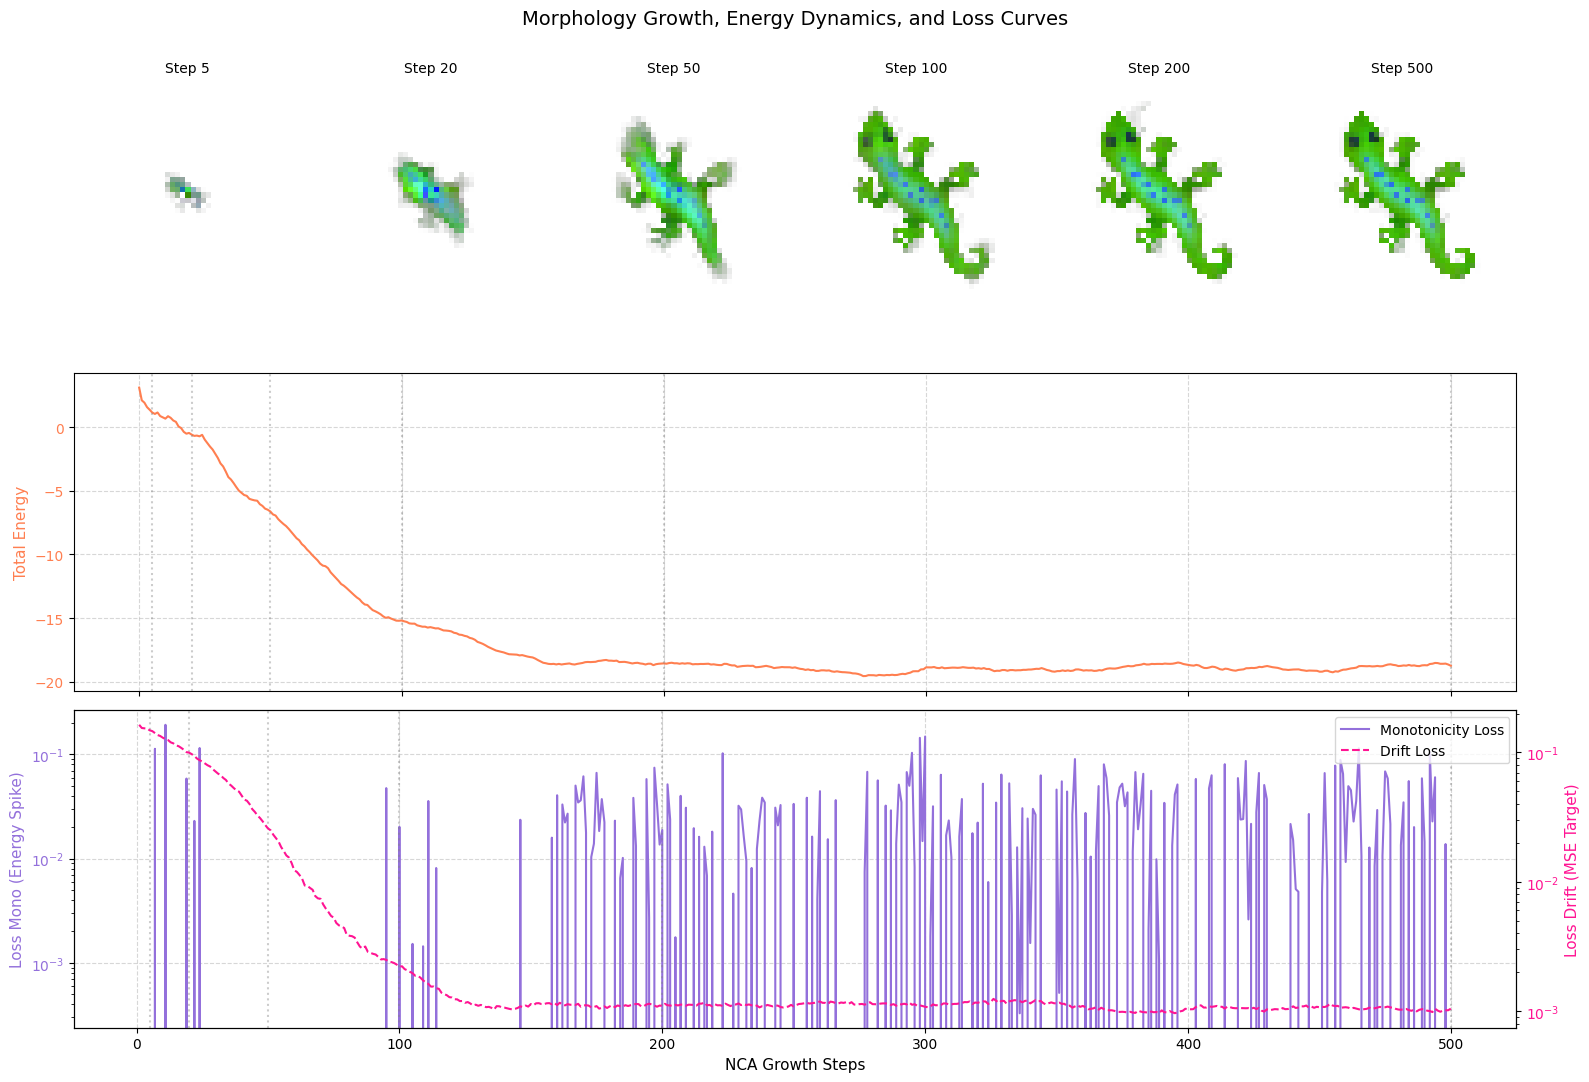

Time to grow: 125 steps


In [19]:
## Growing the morphology
def visualize_growth(nca, seed, base, steps_to_show=[5, 20, 50, 100, 200, 500], device='cuda:0'):
    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base.to(device)

    max_steps = max(steps_to_show)

    # Tracking metrics across steps
    total_energy_history = []
    loss_mono_history = []
    loss_drift_history = []
    captured_frames = []
    mse_log = []

    live_mask = (base_target[:, 3:4] > 0.1).float()

    with torch.no_grad():
      E0 = nca.energy(x)
      total_energy_history.append(E0.sum().item() if torch.is_tensor(E0) else float(E0))
      for step in range(1, max_steps +1 ):
          x = nca(x)

          # MSE loss

          diff = (x[:, :4] - base) * live_mask
          current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
          mse_log.append(current_mse)

          # 1. Total System Energy
          E = nca.energy(x)
          energy_val = E.sum().item() if torch.is_tensor(E) else float(E)
          total_energy_history.append(energy_val)

          # 2. Monotonicity Loss: ReLU(E_{t} - E_{t-1})
          if len(total_energy_history) > 1:
              dE = total_energy_history[-1] - total_energy_history[-2]
              mono_loss = max(0.0, dE)  # Equivalent to torch.relu for scalars
          else:
              mono_loss = 0.0
          loss_mono_history.append(mono_loss)

          # 3. Drift Loss: MSE against target base without mutating main state x
          # Simulates forward rollouts from current state to evaluate drift
          x_rollout = x.clone()
          drift_accum = 0.0
          for _ in range(10):
              x_rollout = nca(x_rollout)
              diff = (base_target[:, :4] - x_rollout[:, :4])
              sq = diff.pow(2) * live_mask
              drift_accum += (sq.sum() / (live_mask.sum() * 4 + 1e-8)).item()

          loss_drift_history.append(drift_accum / 20.0)

          # 4. Capture snapshots at milestone steps
          if step in steps_to_show:
              img = x[0, :4].permute(1, 2, 0).cpu().numpy()
              img = np.clip(img, 0, 1)
              captured_frames.append((step, img))

    # --- Plotting Grid Setup: 3 Rows ---
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle("Morphology Growth, Energy Dynamics, and Loss Curves", fontsize=14, y=0.98)

    steps_range = np.arange(0, max_steps + 1)
    n_snapshots = len(steps_to_show)

    # --- 1. Top Row: Morphological Snapshots ---
    for i, (step, img) in enumerate(captured_frames):
        ax = fig.add_subplot(3, n_snapshots, i + 1)
        ax.imshow(img)
        ax.set_title(f"Step {step}", fontsize=10)
        ax.axis("off")

    # --- 2. Middle Row: Continuous System Energy ---
    ax_energy = fig.add_subplot(3, 1, 2)
    ax_energy.plot(steps_range, total_energy_history, color='coral', linewidth=1.5, label='Total Energy')
    ax_energy.set_ylabel("Total Energy", color='coral', fontsize=11)
    ax_energy.tick_params(axis = 'y', labelcolor = 'coral')
    ax_energy.grid(True, linestyle='--', alpha=0.5)
    ax_energy.set_xticklabels([])  # Hide x-axis ticks for middle plot

    for s in steps_to_show:
        ax_energy.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # --- 3. Bottom Row: Separate Subplot for Loss Mono & Loss Drift ---
    ax_mono = fig.add_subplot(3, 1, 3)
    ax_drift = ax_mono.twinx()  # Dual Y-axis for scale separation

    # Loss Mono Plot (Left Y-Axis)
    steps_loss = steps_range[1:]
    line1 = ax_mono.plot(steps_loss, loss_mono_history, color='mediumpurple', linewidth=1.5, label='Monotonicity Loss')
    ax_mono.set_ylabel("Loss Mono (Energy Spike)", color='mediumpurple', fontsize=11)
    ax_mono.tick_params(axis='y', labelcolor='mediumpurple')
    ax_mono.set_yscale('log')
    ax_mono.set_xlabel("NCA Growth Steps", fontsize=11)
    ax_mono.grid(True, linestyle='--', alpha=0.5)

    # Loss Drift Plot (Right Y-Axis)
    line2 = ax_drift.plot(steps_loss, loss_drift_history, color='deeppink', linewidth=1.5, linestyle='--', label='Drift Loss')
    ax_drift.set_ylabel("Loss Drift (MSE Target)", color='deeppink', fontsize=11)
    ax_drift.tick_params(axis='y', labelcolor='deeppink')
    ax_drift.set_yscale('log')

    # Add milestone step markers to bottom plot
    for s in steps_to_show:
        ax_mono.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # Combined Legend for Bottom Panel
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_mono.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()

    growth_time = find_convergence_step(mse_log)
    if growth_time is None:
        print("Did not converge within the observed window")
    else:
        print(f"Time to grow: {growth_time} steps")

visualize_growth(nca, seed, base)

In [22]:
def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(
            torch.arange(H, device=x.device), torch.arange(W, device=x.device), indexing='ij'
        )
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(
            torch.arange(H, device=x.device), torch.arange(W, device=x.device), indexing='ij'
        )
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x


def visualize_regeneration(nca, seed, base_target, damage='right_half',
                           total_steps=800, damage_step=400,
                           circle_radius=5, device='cuda:0'):

    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base_target.to(device)
    live_mask = (base_target[:, 3:4] > 0.1).float()

    # Metric tracking arrays
    total_energy_history = []
    loss_mono_history = []
    loss_drift_history = []

    frames = []
    frame_titles = []
    capture_steps = [0, damage_step - 1, damage_step, damage_step + 25, damage_step + 150, total_steps - 1]
    loss_recovery = []

    with torch.no_grad():
        for t in range(total_steps):
            # Apply damage at exact step
            if t == damage_step:
                x = apply_damage(x, damage_type=damage, circle_radius=circle_radius)

                # Capture the raw post-damage state BEFORE any recovery step,
                # so recovery time is measured from the true damage event.
                damaged_mse = ((x[:, :4] - base_target) * live_mask).pow(2).sum().item() / (live_mask.sum().item()*4 + 1e-8)
                loss_recovery.append(damaged_mse)

                E_damaged = nca.energy(x)
                total_energy_history.append(E_damaged.sum().item() if torch.is_tensor(E_damaged) else float(E_damaged))
                loss_mono_history.append(0.0)  # no prior state to compare against yet this step

            # Step forward
            x = nca(x)
            diff = (x[:, :4] - base_target) * live_mask
            current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
            loss_recovery.append(current_mse)

            # 1. Total System Energy
            E = nca.energy(x)
            energy_val = E.sum().item() if torch.is_tensor(E) else float(E)
            total_energy_history.append(energy_val)

            # 2. Monotonicity Loss: ReLU(E_t - E_{t-1})
            if len(total_energy_history) > 1:
                dE = total_energy_history[-1] - total_energy_history[-2]
                mono_loss = max(0.0, dE)
            else:
                mono_loss = 0.0
            loss_mono_history.append(mono_loss)

            # 3. Drift Loss: 20-step forward rollout without mutating x
            x_rollout = x.clone()
            drift_accum = 0.0
            for r_step in range(20):
                x_rollout = nca(x_rollout, step=t + r_step) if 'step' in nca.forward.__code__.co_varnames else nca(x_rollout)
                diff = (base_target[:, :4] - x_rollout[:, :4]) * live_mask
                drift_accum += diff.pow(2).mean().item()

            loss_drift_history.append(drift_accum / 20.0)

            # 4. Capture Frame Snapshots
            if t in capture_steps:
                frame_img = x[0, :4].permute(1, 2, 0).cpu().clamp(0, 1).numpy()
                frames.append(frame_img)

                if t < damage_step:
                    frame_titles.append(f't={t} (Growth)')
                elif t == damage_step:
                    frame_titles.append(f't={t} (Damaged)')
                else:
                    frame_titles.append(f't={t} (+{t - damage_step})')

    # --- Plotting Grid Setup: 3 Rows ---
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle(f"Morphology Regeneration Dynamics (Damage: '{damage}' at Step {damage_step})", fontsize=14, y=0.98)

    # total_energy_history / loss_mono_history now have one extra entry
    # (the damage-step capture) relative to total_steps, so build a matching x-axis.
    steps_range = np.arange(len(total_energy_history))
    n_frames = len(frames)

    # --- 1. Top Row: Regeneration Snapshots ---
    for i, (frame, title) in enumerate(zip(frames, frame_titles)):
        ax = fig.add_subplot(3, n_frames, i + 1)
        ax.imshow(frame)
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    # --- 2. Middle Row: System Energy Profile ---
    ax_energy = fig.add_subplot(3, 1, 2)
    ax_energy.plot(steps_range, total_energy_history, color='coral', linewidth=1.5, label='System Energy')
    ax_energy.axvline(x=damage_step, color='red', linestyle='--', linewidth=1.5, label='Damage Event')
    ax_energy.set_ylabel("Total Energy", color='coral', fontsize=11)
    ax_energy.grid(True, linestyle='--', alpha=0.5)
    ax_energy.tick_params(axis = 'y', labelcolor = 'coral')
    ax_energy.set_xticklabels([])
    ax_energy.legend(loc='upper right')

    for s in capture_steps:
        ax_energy.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # --- 3. Bottom Row: Loss Mono & Loss Drift Dual-Axis ---
    ax_mono = fig.add_subplot(3, 1, 3)
    ax_drift = ax_mono.twinx()

    # Monotonicity Loss (Left Y-Axis)
    line1 = ax_mono.plot(steps_range, loss_mono_history, color='mediumpurple', linewidth=1.2, label='Monotonicity Loss')
    ax_mono.set_ylabel("Loss Mono", color='mediumpurple', fontsize=11)
    ax_mono.tick_params(axis='y', labelcolor='mediumpurple')
    ax_mono.set_yscale('log')
    ax_mono.set_xlabel("NCA Rollout Steps", fontsize=11)
    ax_mono.grid(True, linestyle='--', alpha=0.5)

    # Drift Loss (Right Y-Axis) — one entry per t, unaffected by the damage-step extra append
    line2 = ax_drift.plot(np.arange(total_steps), loss_drift_history, color='deeppink', linewidth=1.2, linestyle='--', label='Drift Loss')
    ax_drift.set_ylabel("Loss Drift (MSE Target)", color='deeppink', fontsize=11)
    ax_drift.tick_params(axis='y', labelcolor='deeppink')
    ax_drift.set_yscale('log')

    # Damage Event & Capture Markers
    ax_mono.axvline(x=damage_step, color='red', linestyle='--', linewidth=1.5)
    for s in capture_steps:
        ax_mono.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # Combined Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_mono.legend(lines, labels, loc='upper right')

    # Recovery time measured from the true damage-step MSE onward
    damage_idx_in_recovery = capture_steps.index(damage_step) if damage_step in capture_steps else None
    # loss_recovery has the extra pre-recovery entry inserted at damage_step,
    # so the post-damage slice starts one index later than damage_step in this array.
    post_damage_start = sum(1 for s in range(damage_step + 1))  # = damage_step + 1 entries logged before/at damage
    post_damage_mse = loss_recovery[damage_step:]  # includes the injected damaged_mse as its first element
    recovery_step = find_convergence_step(post_damage_mse, patience=10, delta_tol=1e-4, target_mse=0.005)

    if recovery_step is None:
        print("Did not recover within the observed window")
    else:
        print(f"Time to recover after damage: {recovery_step} steps")

    plt.tight_layout()
    plt.show()




Did not recover within the observed window


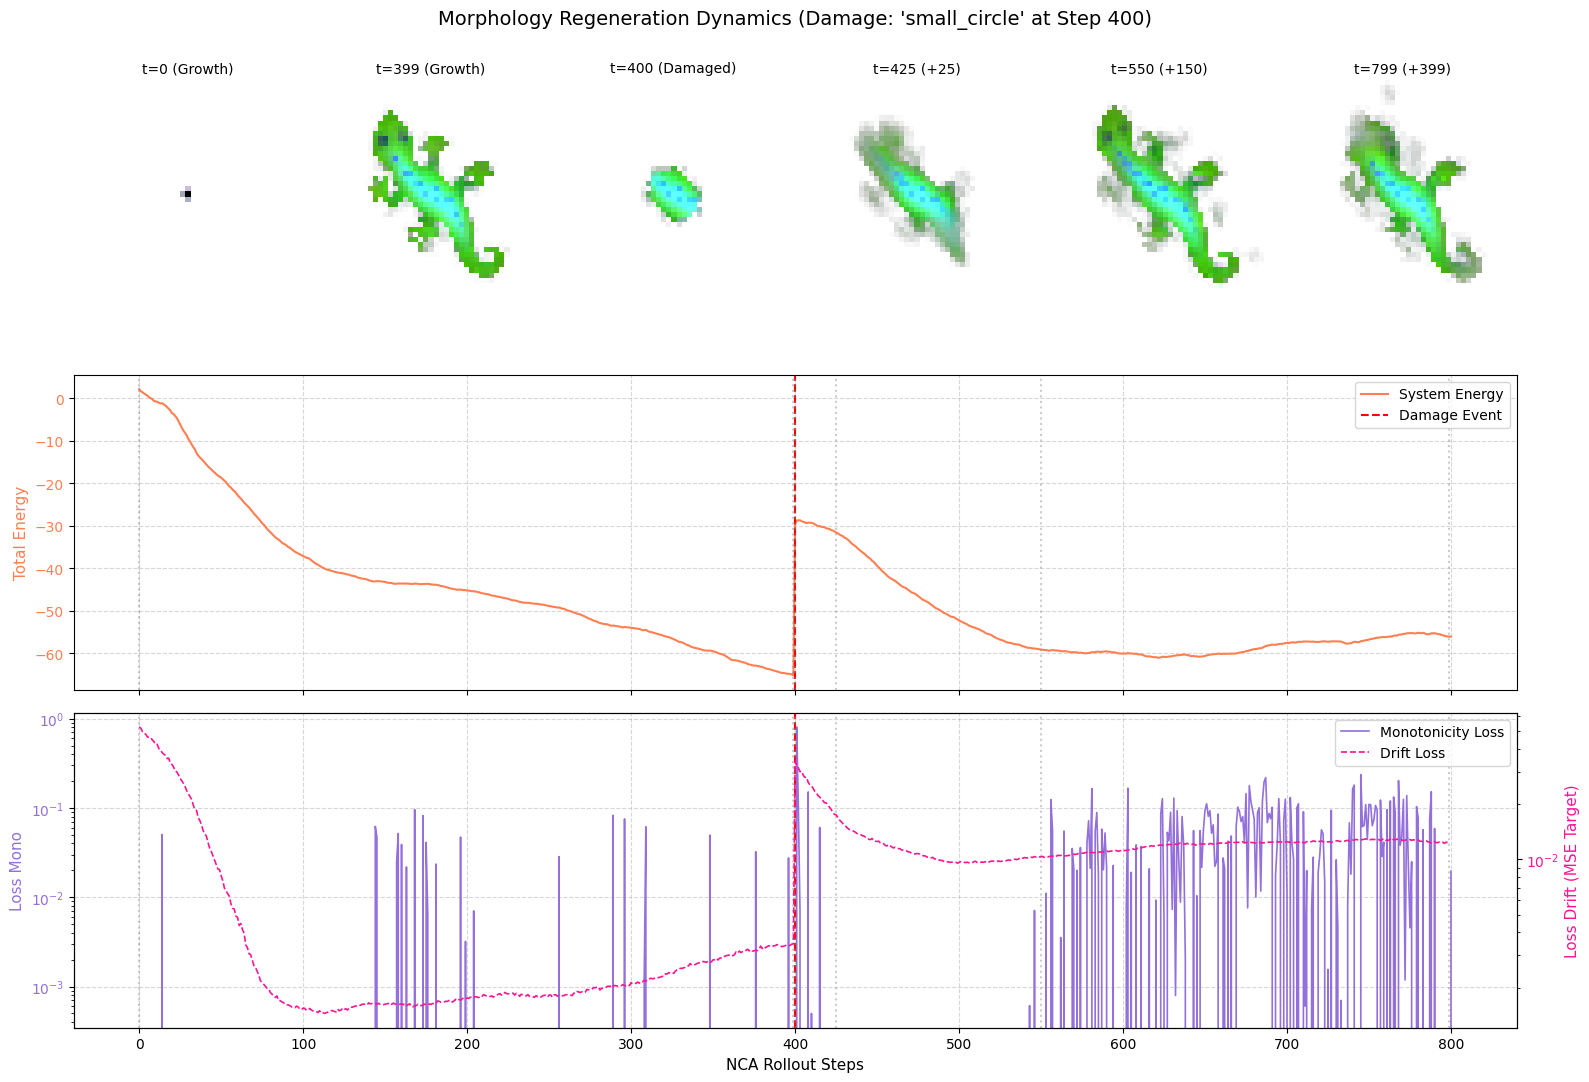

In [23]:
visualize_regeneration(nca, seed, base, "small_circle")

In [ ]:
def benchmark_recovery_times(nca, seed, base_target,
                              damage_types=('right_half', 'left_half', 'center_circle',
                                            'small_circle', 'random', 'cross'),
                              n_trials=10, total_steps=800, damage_step=400,
                              circle_radius=5, device='cuda:0',
                              patience=10, delta_tol=1e-4, target_mse=0.005):
    """
    Runs n_trials independent regeneration rollouts per damage type and
    returns a table (pandas DataFrame) with mean/std recovery time and
    recovery rate — no plotting.
    """
    rows = []

    for damage in damage_types:
        recovery_times = []
        final_MSES = []  # Reset for each damage type
        n_recovered = 0

        # Run all trials for the current damage type
        for trial in range(n_trials):
            recovery_step, final_mse = measure_recovery_time_only(
                nca, seed, base_target,
                damage=damage, total_steps=total_steps, damage_step=damage_step,
                circle_radius=circle_radius, device=device,
                patience=patience, delta_tol=delta_tol, target_mse=target_mse
            )
            final_MSES.append(final_mse)

            if recovery_step is not None:
                recovery_times.append(recovery_step)
                n_recovered += 1

        # Calculate statistics after completing all n_trials
        mean_mse = float(np.mean(final_MSES))
        std_mse = float(np.std(final_MSES))

        if len(recovery_times) > 0:
            mean_time = float(np.mean(recovery_times))
            std_time = float(np.std(recovery_times))
        else:
            mean_time = float('nan')
            std_time = float('nan')

        rows.append({
            'damage_type': damage,
            'n_trials': n_trials,
            'n_recovered': n_recovered,
            'recovery_rate': n_recovered / n_trials,
            'mean_recovery_time': mean_time,
            'std_recovery_time': std_time,
            'mean MSE': mean_mse,
            'std MSE': std_mse
        })

    return pd.DataFrame(rows)

In [ ]:
results_df = benchmark_recovery_times(nca, seed, base, n_trials=20)
results_df

NameError: name 'measure_recovery_time_only' is not defined

In [ ]:
def plot_attractor_phase_portrait(nca, seed, base_target, steps=300, device='cuda:0'):
    base_target = base_target.to(device)

    if isinstance(seed, np.ndarray):
        init_seed = torch.from_numpy(seed[None, ...]).to(device) if seed.ndim == 3 else torch.from_numpy(seed).to(device)
    else:
        init_seed = seed.clone().to(device)
    if init_seed.ndim == 3:
        init_seed = init_seed.unsqueeze(0)

    def get_feat(state):
        f = nca.perceive(state) if hasattr(nca, 'perceive') else state
        return f[0].cpu().numpy().flatten()

    # Grow baseline AND capture its own trajectory
    with torch.no_grad():
        x_base = init_seed.clone()
        seed_traj = [get_feat(x_base)]
        for _ in range(steps):
            x_base = nca(x_base)
            seed_traj.append(get_feat(x_base))
    seed_traj = np.array(seed_traj)

    # Perturbed starting states, all cloned from the converged x_base
    init_half         = apply_damage(x_base.clone(), damage_type='right_half', circle_radius=5)
    init_hole         = apply_damage(x_base.clone(), damage_type='center_circle', circle_radius=5)
    init_small_circle = apply_damage(x_base.clone(), damage_type='small_circle', circle_radius=5)
    init_cross         = apply_damage(x_base.clone(), damage_type='cross')
    init_memory_wipe  = x_base.clone()
    init_memory_wipe[:, 4:] = 0.0

    starting_states = [init_half, init_hole, init_small_circle, init_cross, init_memory_wipe]
    labels = ['Half Cut Damage', 'Center Hole Punch', 'Small circle mask', 'Cross section', 'Hidden Memory Reset']
    colors = ['darkred', 'orangered', 'forestgreen', 'magenta', 'purple']

    trajectories = [seed_traj]

    with torch.no_grad():
        for start_state in starting_states:
            x = start_state.clone()
            traj = [get_feat(x)]
            for t in range(steps):
                x = nca(x)
                traj.append(get_feat(x))
            trajectories.append(np.array(traj))

    labels = ['Seed Growth'] + labels
    colors = ['deepskyblue'] + colors

    with torch.no_grad():
        target_flat = get_feat(x_base)[None, :]

    all_states = np.concatenate(trajectories + [target_flat], axis=0)
    pca = PCA(n_components=2)
    pca.fit(all_states)
    target_2d = pca.transform(target_flat)

    plt.figure(figsize=(9, 7))
    for traj, color, label in zip(trajectories, colors, labels):
        traj_2d = pca.transform(traj)
        plt.plot(traj_2d[:, 0], traj_2d[:, 1], color=color, alpha=0.85, linewidth=1.8, label=label)
        plt.scatter(traj_2d[0, 0], traj_2d[0, 1], color=color, marker='o', s=60)
        plt.scatter(traj_2d[-1, 0], traj_2d[-1, 1], color=color, marker='X', s=90)

    plt.scatter(target_2d[0, 0], target_2d[0, 1], color='gold', edgecolor='black',
                marker='*', s=350, zorder=5, label='Attractor in the phase portrait')

    plt.xlabel('Principal Component 1', fontsize=11)
    plt.ylabel('Principal Component 2', fontsize=11)
    plt.title('Phase Portrait: Converging Trajectories under Structural Damage', fontsize=13)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()



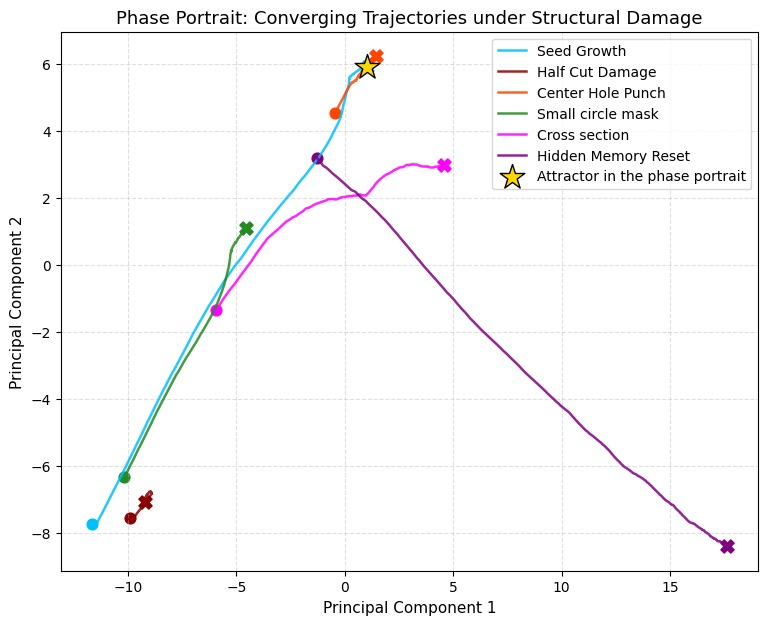

In [ ]:
plot_attractor_phase_portrait(nca,seed, base)